## Example 1: Seismic Model Generation

This example demonstrates the use of **ModGen2D** to generate **multiple spatially correlated seismic property fields** for a typical **P-wave refraction scenario**. Refer **detailed version** for step-wise description.

### Model Replication and Automation
This **multiple version** of the example demonstrates how to generate multiple model realizations in a systematic and reproducible manner. For this and other examples, the individual cells from the **detailed version** can be consolidated into a single model-generation function. 

Multiple realizations can be generated efficiently by repeatedly calling the function with different model_id values by defining:
1. a random number generator (RNG) seed, and
2. a function parameterized by a model identifier (model_id),



This approach promotes reproducibility, scalability, and cleaner notebook structure, while preserving the same modeling logic presented in the detailed version.

In [1]:
import sys, importlib
sys.path.insert(0, r'F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator')

In [2]:
import modgen2d as mg

(<Axes: title={'center': 'Main_property_name:miu'}, xlabel='X', ylabel='Z'>,
 np.float64(0.0),
 np.float64(0.4999))

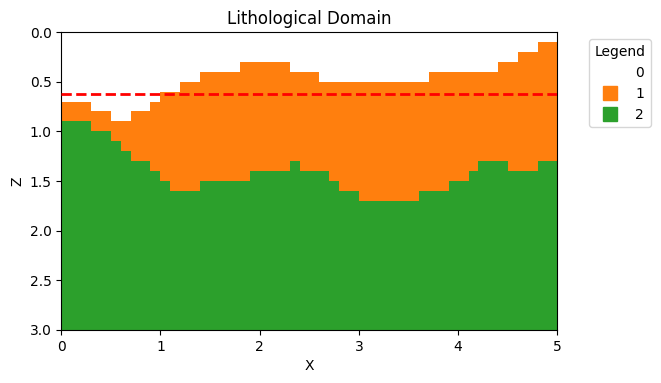

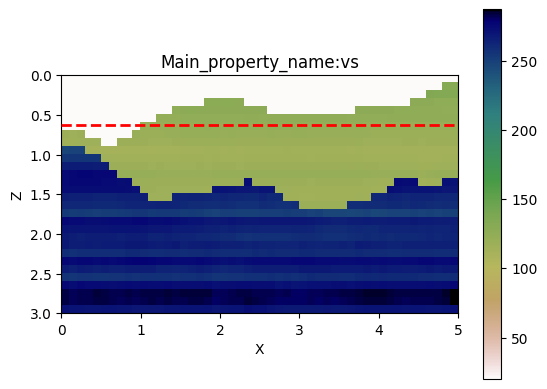

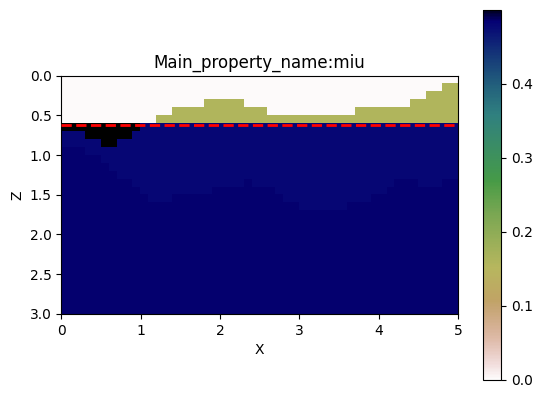

In [8]:
model_id = 1
to_h5 = f'generated_h5_files/{model_id:08d}.h5'

gen_profiles = mg.read_hdf5_file(to_h5)
gen_profiles.merged_generated_model2d.plot_lit_domain()
# gen_profiles.merged_generated_model2d.plot_profile('z_vals_seismic')
gen_profiles.merged_generated_model2d.plot_profile('vs')
gen_profiles.merged_generated_model2d.plot_profile('miu')

In [9]:
def plot_profile(gen_profile_like, main_property_like, new_simulated_profile, ax=None, discrete_point_size=0, plot_gwt = True,
               vlog = False, vmin=None, vmax=None, cmap='gist_earth_r', 
               title = 'auto', legend = True, legend_label = None, legendkwargs_dict={}):
        """
        Plots a 2D property profile.

        Parameters
        ----------
        gen_profile_like:
            replicates domain and properties shape from gen_profile_like
        main_property_like : str
            replicates simulated profile shape from this main_property name.
        new_simulated_profile:
            array of same shape as main_property_like, to plot.
        ax : matplotlib.axes.Axes, optional
            Matplotlib axes to plot on.
        discrete_point_size : float, default 0
            Size of scatter points.
        plot_gwt : bool, default True
            Plot groundwater table.
        vlog : bool, default False
            Apply logarithmic normalization.
        vmin, vmax : float, optional
            Color scale limits.
        cmap : str or Colormap, default 'gist_earth_r'
            Colormap.
        title : str, default 'auto'
            Plot title.
        legend : bool, default True
            Show colorbar.
        legend_label : str, optional
            Colorbar label.
        legendkwargs_dict : dict, optional
            Extra keyword arguments for colorbar.

        Returns
        -------
        ax : matplotlib.axes.Axes
            Axes containing the plot.
        vmin : float
            Minimum value used for colormap.
        vmax : float
            Maximum value used for colormap.
        """
        if ax is None:
            fig,ax = plt.subplots()

        simulated_profile_set = gen_profile_like.simulated_profiles
        domain = gen_profile_like.lit_domain.domain
        z_centers, x_centers = domain.z_centers, domain.x_centers
        span_x, span_z = domain.spans
        
        if main_property_like not in simulated_profile_set.keys():
            raise ValueError(f"main_property_name: {main_property_like} not generated yet.")
        
        data = simulated_profile_set[main_property_like]

        if data.shape != new_simulated_profile.shape:
            raise ValueError(f"Shape mismatch. Expected: {data.shape}. Got {new_simulated_profile.shape}")

        data = new_simulated_profile.T
        extent=[0, span_x, span_z, 0]
        # Create a colormap from the color mapping
        if vmin is None:
            vmin = np.min(data)

        if vmax is None:
            vmax = np.max(data)
            
        if vlog:
            norm = LogNorm(vmin=vmin, vmax=vmax)
            cax = ax.imshow(data, norm=norm, cmap=cmap, extent=extent, interpolation='none') 
        else:
            cax = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, extent=extent, interpolation='none') 
        
        # Plot gwt
        if gen_profile_like.lit_domain.gwt_depth is not None and plot_gwt:
            edges_kw = dict(color='r', linestyle='dashed', linewidth=2, zorder=4000)
            ax.plot([0, span_x], [gen_profile_like.lit_domain.gwt_depth, gen_profile_like.lit_domain.gwt_depth], **edges_kw)

        x_data, z_data = np.meshgrid(x_centers, z_centers, indexing='ij')
        if discrete_point_size!=0:
            ax.scatter(x_data.flatten(), z_data.flatten(), c = 'k', s=discrete_point_size)
        
        if title=='auto':
            ax.set_title(f"Main_property_name:{main_property_like}")
        
        # Colorbar
        # if legendkwargs_dict is None:
        #     legendkwargs_dict = {
        #         'shrink':0.6,
        #         'aspect':20,
        #         'pad':0.1
        #     }
        
        if legend:
            cbar = plt.colorbar(cax, ax=ax, **legendkwargs_dict)
            cbar.set_label(legend_label)
        
        ax.axis('scaled')
        ax.set(
            xlim= [0, span_x],
            ylim= [span_z, 0],
            xlabel='X',
            ylabel='Z',
        )

        return ax, vmin, vmax
    

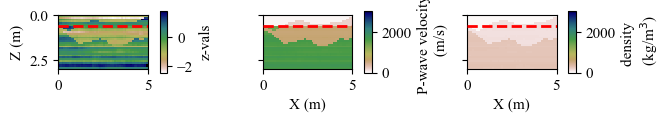

In [10]:
# Figure 7
import example1_helper_functions as hf
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.family'] = "serif"
matplotlib.rcParams['font.serif']= ['Times New Roman'] + plt.rcParams['font.serif']
matplotlib.rcParams['font.size'] = 11

fig, axs = plt.subplots(1, 3, figsize=(7, 10/4), sharex=True, sharey=True)

legendkwargs_dict = {
    'shrink':0.3,
    'aspect':8,
    'pad':0.1
}


ax = axs[0]
gen_profiles.merged_generated_model2d.plot_profile('z_vals_seismic', ax=ax, legend_label = 'z-vals', legendkwargs_dict=legendkwargs_dict)
ax.set(ylabel="Z (m)", xlabel=None, title=None)


ax = axs[1]
# compute Vp
vs_profile = gen_profiles.merged_generated_model2d.simulated_profiles['vs']
miu_profile = gen_profiles.merged_generated_model2d.simulated_profiles['miu']
vp_profile = hf.Vp_profile(vs_profile, miu_profile)
plot_profile(gen_profiles.merged_generated_model2d, 'vs', vp_profile, ax=ax, vmin=0, vmax=3000, legend_label = 'P-wave velocity \n (m/s)', legendkwargs_dict=legendkwargs_dict)
ax.set(ylabel=None, xlabel="X (m)", title=None)


ax = axs[2]
gen_profiles.merged_generated_model2d.plot_profile('vs', ax=ax, vmin=0, vmax=3000, legend_label = 'density \n (kg/m$^3$)', legendkwargs_dict=legendkwargs_dict)
ax.set(ylabel=None, xlabel="X (m)", title=None)

# ax = axs[1]
# gen_profiles.merged_generated_model2d.plot_profile('miu', ax=ax)

fig.tight_layout(rect=[0.05, 0.05, 1, 1])  # Leave space for shared labels
fig.savefig(r"F:\V_Tech Semesters\MS Thesis\Jupyter_MS\Papers_figures\Geomodgen2d_paper\Figure9_raw.svg", format="svg", bbox_inches='tight', metadata={'Creator':'Matplotlib'})

# ax.set(yscale='log', ylabel=None, xlabel=None, ylim=[0,1], title=None)


# gen_profiles.get_generated_model2d('z_vals_seismic')


In [33]:
print(hf.Vp_profile(20, miu_profile=0.4999))
print(hf.Vp_profile(20, miu_profile=0.5))

1414.3549766590493


ZeroDivisionError: float division by zero